In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', version=1, parser='auto')

In [ ]:
# Tách features và labels
X = mnist.data.astype('float32') # Shape: (70000, 784)
y = mnist.target.astype('int') # Shape: (70000,)

print(f"Shape của X: {X.shape}")
print(f"Shape của y: {y.shape}")
print(f"Giá trị pixel: min={X.min()}, max={X.max()}")

Shape của X: (70000, 784)
Shape của y: (70000,)
Giá trị pixel: min=pixel1      0.0
pixel2      0.0
pixel3      0.0
pixel4      0.0
pixel5      0.0
           ... 
pixel780    0.0
pixel781    0.0
pixel782    0.0
pixel783    0.0
pixel784    0.0
Length: 784, dtype: float32, max=pixel1       0.0
pixel2       0.0
pixel3       0.0
pixel4       0.0
pixel5       0.0
            ... 
pixel780    62.0
pixel781     0.0
pixel782     0.0
pixel783     0.0
pixel784     0.0
Length: 784, dtype: float32


In [17]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (60000, 28, 28), Test: (10000, 28, 28)


In [19]:
# Ảnh 28x28 cần chuyển thành vector 784 chiều
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
# Nếu load từ sklearn thì đã flat sẵn (70000, 784)
print(f"Shape sau flatten: {X_train_flat.shape}")

Shape sau flatten: (60000, 784)


In [21]:
# Chia cho 255 để đưa về khoảng [0, 1]
X_train_normalized = X_train_flat / 255.0
X_test_normalized = X_test_flat / 255.0
print(f"Giá trị sau chuẩn hóa: min = {X_train_normalized.min()}, max = {X_train_normalized.max()}")


Giá trị sau chuẩn hóa: min = 0.0, max = 1.0


In [25]:
from sklearn.linear_model import LogisticRegression
#Tạo mô hình
model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=100,
    tol=0.1,
    verbose=1,
    n_jobs=-1,
    random_state=42
) 

In [27]:
import time 
print ("Bắt đầu")
start_time = time.time()

#Train trên 60k ảnh
model.fit(X_train_normalized, y_train)

end_time = time.time()
print(f"Hoàn thành sau {end_time - start_time: 2f} giây")

Bắt đầu


/home/vophilong/Documents/BTap_DeepLearning/BaiTapDeepLearning/deep_learning/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.25176129
Epoch 3, change: 0.13448236
Epoch 4, change: 0.1049112
convergence after 5 epochs took 6 seconds
Hoàn thành sau  5.793447 giây


In [30]:
# Dự đoán cho 10,000 ảnh test
y_pred = model.predict(X_test_normalized)
# Xem một số dự đoán
print("10 dự đoán đầu tiên:", y_pred[:10])
print("10 nhãn thực tế:", y_test[:10])
# Dự đoán xác suất
y_pred_proba = model.predict_proba(X_test_normalized)
print("\nXác suất cho ảnh đầu tiên:")
print(y_pred_proba[0])
print(f"Dự đoán: {y_pred[0]}, Xác suất: {y_pred_proba[0][y_pred[0]]:.4f}")


10 dự đoán đầu tiên: [7 2 1 0 4 1 4 9 6 9]
10 nhãn thực tế: [7 2 1 0 4 1 4 9 5 9]

Xác suất cho ảnh đầu tiên:
[1.16123157e-05 1.19017102e-10 3.14816215e-05 3.51496725e-03
 4.63388501e-07 1.98750952e-05 3.80985835e-10 9.96074273e-01
 1.19334138e-05 3.35393162e-04]
Dự đoán: 7, Xác suất: 0.9961


In [32]:
#Tính accuracy
from sklearn.metrics import accuracy_score
train_acc = model.score(X_train_normalized, y_train)
test_acc = model.score(X_test_normalized, y_test)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9297
Test Accuracy: 0.9242


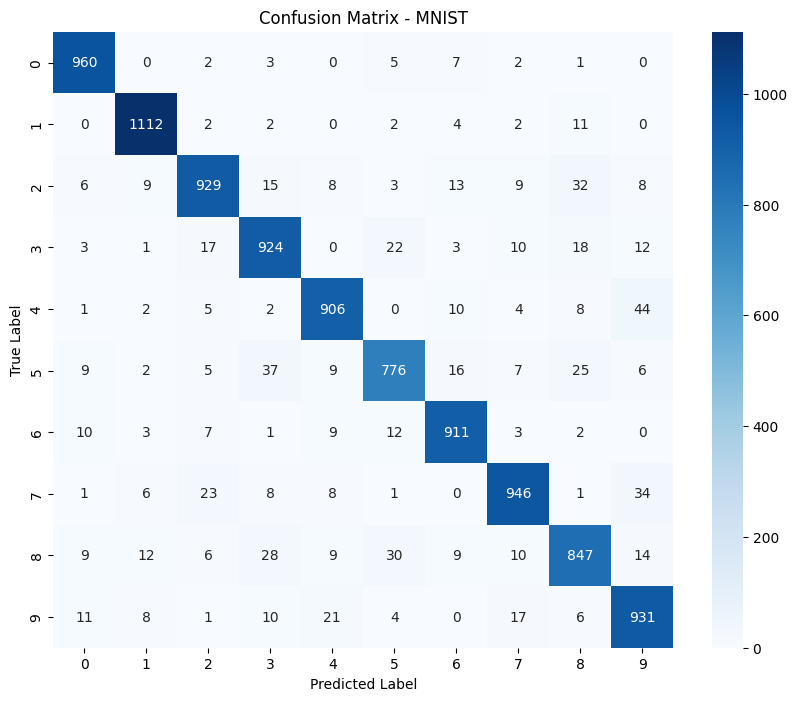

In [33]:
#Vẽ ma trận nhầm lẫn
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST')
plt.show()

In [ ]:
# Tìm các mẫu dự đoán sai
import numpy as np
incorrect_indices = np.where(y_pred != y_test)[0]
print(f"Số lượng dự đoán sai: {len(incorrect_indices)}")
# Visualize một số ảnh dự đoán sai
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.ravel()
for i, idx in enumerate(incorrect_indices[:15]):axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
axes[i].set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
axes[i].axis('off')
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined